# Fashion MNIST

## Integrantes:

Pedro Henrique Macedo Antunes

Kevin Teixeira Carvalho

Diogo Lima de Oliveira

## Fonte:
 https://www.kaggle.com/datasets/zalando-research/fashionmnist

## Objetivo:
 Gerar um modelo de ML classificador, capaz de classisficar diferentes imagens do dataset 'Fashion MNIST', feito para benchmark de modelos de ML, assim como o MNIST, porém mais complexo, por que o MNIST é tão simples que qualquer modelo consegue uma boa pontuação com ele.

 "The original MNIST dataset contains a lot of handwritten digits. Members of the AI/ML/Data Science community love this dataset and use it as a benchmark to validate their algorithms. In fact, MNIST is often the first dataset researchers try. "If it doesn't work on MNIST, it won't work at all", they said. "Well, if it does work on MNIST, it may still fail on others."

Zalando seeks to replace the original MNIST dataset"

## Atributo alvo:
Tipo de peça de roupa (shirt, t-shirt, trouser, dress ...)

## Atributo preditivo:
Imagem (cada pixel)

## Tipo da tarefa:
Classificação

## Compreensão e análise de dados
Nessa parte do notebook, iremos visualizar e analisar os dados.

In [1]:
import sklearn
import kagglehub
import pandas as pd

In [2]:
# Salvando o dataset a partir do kaggle.
train_df = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "zalando-research/fashionmnist",
    "fashion-mnist_train.csv"
)

test_df = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "zalando-research/fashionmnist",
    "fashion-mnist_test.csv"
)

print(train_df.shape)
print(test_df.shape)

100%|██████████| 33.6M/33.6M [00:02<00:00, 12.5MB/s]

Extracting zip of fashion-mnist_train.csv...


Using Colab cache for faster access to the 'fashionmnist' dataset.
(60000, 785)
(10000, 785)


## Analisando o tipo de dado e balanceamento do dataset

In [3]:
content = train_df.iloc[0]
print(content)

label       2
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 0, Length: 785, dtype: int64


In [4]:
print(train_df['label'].value_counts())
print(test_df['label'].value_counts())

label
2    6000
9    6000
6    6000
0    6000
3    6000
4    6000
5    6000
8    6000
7    6000
1    6000
Name: count, dtype: int64
label
0    1000
1    1000
2    1000
3    1000
8    1000
6    1000
5    1000
4    1000
7    1000
9    1000
Name: count, dtype: int64


Isso nos mostra que, o dado é no formato:

label, (imagem)

Em que label é o rótulo do dado, e imagem são os pixels da imagem 28x28, representados por números inteiros int64.

Além disso, o dataset é balanceado.


## Análise do df como um todo

In [5]:
# Junta o conjunto de teste e treino
df = pd.concat([train_df, test_df], ignore_index=True)
count, size = df.shape
# Separa label dos pixels
X = df.drop('label', axis=1)
y = df['label']

print("Valores ausentes?")
# Se há valores ausentes, dentro das imagens
print(df.isnull().sum().sum())

print("Imagens duplicadas?")
# Se há valores duplicados
dup = df.duplicated().sum()
print(dup)
dup = (dup/count*100)*1000
dup = round(dup)
dup = dup/1000
print(f"Porcentagem: {dup}%")

# Os valores dos pixels estão entre 0 e 255?
X_desc = X.describe()
print(X_desc.loc[['min', 'max']])

Valores ausentes?
0
Imagens duplicadas?
53
Porcentagem: 0.076%
     pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
min     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
max    16.0    45.0   226.0   185.0   227.0   230.0   247.0   255.0   254.0   

     pixel10  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
min      0.0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
max    255.0  ...     255.0     255.0     255.0     255.0     255.0     255.0   

     pixel781  pixel782  pixel783  pixel784  
min       0.0       0.0       0.0       0.0  
max     255.0     255.0     255.0     170.0  

[2 rows x 784 columns]


Ao analisar os dados, é possível concluir que, não há valores ausente e os pixels sempre tem de 0 a 255 em sua escala.

Porém, existem imagens duplicadas, interessante, vamos explorar elas.

Queremos saber, primeiramente, se há alguma imagem duplicada no test e train

In [6]:
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())

43
1


Como existem mais imagens duplicadas no df junto no que nos dfs separados e somados, é possível concluir que existem sim imagens iguais no train e no test!

#Gráficos

In [7]:
# Importações
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

<Axes: >

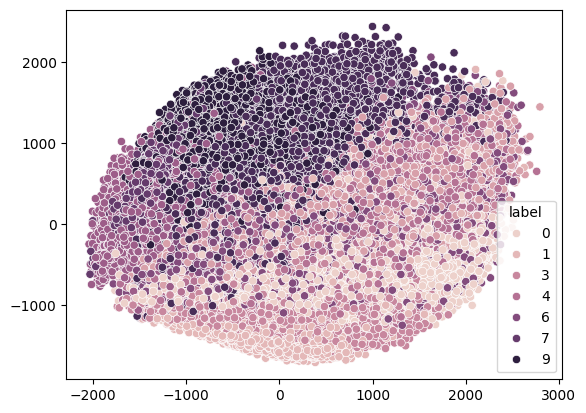

In [8]:
pca = PCA(n_components=2); X_pca = pca.fit_transform(X)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y)

A partir do gráfico, é possível ver que enquanto é possível distinguir cada classe, ainda há um overlap entre elas. Ou seja, erros nas áreas com overlap

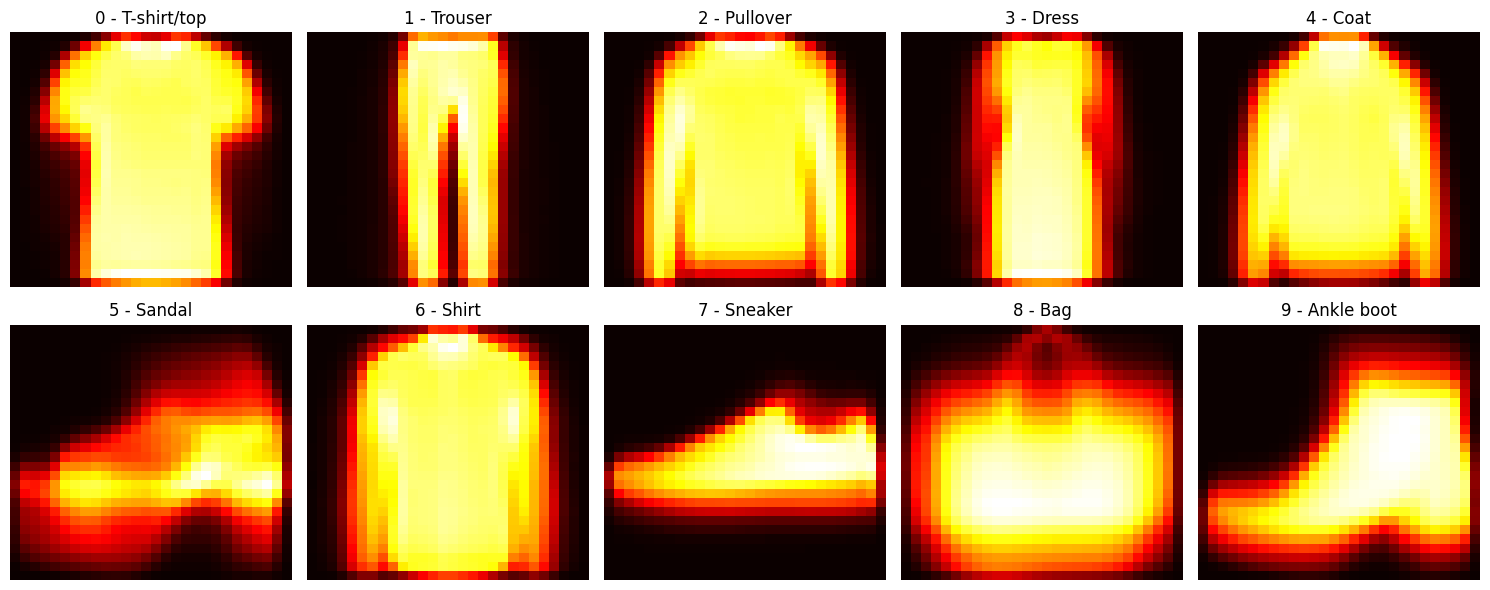

In [9]:
X = df.drop('label', axis=1)
y = df['label']

class_means = X.groupby(y).mean()

# Nome de cada rótulo
labels_names = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):

    img_media = class_means.loc[i].values.reshape(28, 28)

    heatmap = sns.heatmap(img_media, ax=ax, cmap='hot', cbar=False,
                          xticklabels=False, yticklabels=False)

    ax.set_title(f'{i} - {labels_names[i]}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

A partir do heatmap é possível enxergar a "média" de cada peça, é possível ver como, realmente, existe um overlap entre algumas classes, principalmente com Trouser, Coat e Shirt, e Sandal, Sneaker e Ankle Boot

# Pré-Processamento

**Normalização**:

Problema:
Os valores dos pixels das imagens variam entre 0 e 255, o que pode dificultar o treinamento da rede neural, tornando a convergência mais lenta e menos estável.

Tratamento:
Foi realizada a normalização dos pixels, dividindo todos os valores por 255, fazendo com que passem a variar entre 0 e 1.

Motivo:
Porque a normalização coloca todas as entradas na mesma escala, facilitando o aprendizado da rede neural, acelerando a convergência do treinamento e contribuindo para uma maior estabilidade do processo de otimização.

In [10]:
X = X / 255.0
print(X.iloc[:5])

   pixel1  pixel2  pixel3    pixel4    pixel5  pixel6  pixel7    pixel8  \
0     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0  0.000000   
1     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0  0.000000   
2     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0  0.019608   
3     0.0     0.0     0.0  0.003922  0.007843     0.0     0.0  0.000000   
4     0.0     0.0     0.0  0.000000  0.000000     0.0     0.0  0.000000   

   pixel9  pixel10  ...  pixel775  pixel776  pixel777  pixel778  pixel779  \
0     0.0      0.0  ...  0.000000       0.0       0.0  0.000000  0.000000   
1     0.0      0.0  ...  0.000000       0.0       0.0  0.000000  0.000000   
2     0.0      0.0  ...  0.000000       0.0       0.0  0.117647  0.168627   
3     0.0      0.0  ...  0.011765       0.0       0.0  0.000000  0.000000   
4     0.0      0.0  ...  0.000000       0.0       0.0  0.000000  0.000000   

   pixel780  pixel781  pixel782  pixel783  pixel784  
0  0.000000       0.0       0.0 

**Remoção de Duplicatas**

Problema: O conjunto de treinamento possui algumas duplicatas (imagens identicas umas as outras) atrapalhando na identificação de padrões, por ele já ter noção da classe da imagem, trazendo uma ideia mais de memorização.

Tratamento: A Remoção de Duplicatas faz a detecção de quantas imagems semelhantes existem no dataset e as removem.

Motivo: A Remoção de Duplicatas consegue retirar essas imagens, permitindo uma melhor identificação de padrões no dataset.

In [11]:
import numpy as np
import tensorflow as tf

# Junta X e y
df = pd.DataFrame(X)
df["label"] = y

# Conta duplicatas
duplicatas = df.duplicated().sum()
print("Duplicatas:", duplicatas)

# Remove duplicatas
df = df.drop_duplicates()

print("Duplicatas restantes:", df.duplicated().sum())

# Separa novamente
X = df.drop("label", axis=1).values
y = df["label"].values

# Separa novamente
X = df.drop("label", axis=1).values
y = df["label"].values

print("Quantidade de imagens:", X.shape[0])

Duplicatas: 53
Duplicatas restantes: 0
Quantidade de imagens: 69947


**Data Augmentetion**:

Problema:
O conjunto de treinamento possui uma quantidade limitada de imagens, o que pode fazer com que o modelo memorize os exemplos de treino (overfitting) e tenha dificuldade para generalizar para novas imagens, alem do dataset diminuir ao retirar as duplicatas.

Tratamento:
O Data Augmentation consegue gerar novas variações das imagens de treinamento por meio de pequenas rotações, translações e zoom, sem alterar a classe das roupas.

Motivo:
O Data Augmentation aumenta artificialmente a diversidade dos dados de treinamento, reduz o overfitting e torna o modelo mais robusto a pequenas variações nas imagens, conseguindo usar no lugar das duplicatas

In [12]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1)
])

if len(X.shape) == 2:
    X = X.reshape(-1, 28, 28, 1)

# Escolhe aleatoriamente as imagens que serão aumentadas
indices = np.random.choice(X.shape[0], duplicatas, replace=False)

# Gera novas imagens
X_aug = data_augmentation(X[indices], training=True).numpy()

# Mantém os mesmos rótulos
y_aug = y[indices]

# Adiciona ao conjunto
X = np.concatenate([X, X_aug], axis=0)
y = np.concatenate([y, y_aug], axis=0)

print("Quantidade final de imagens:", X.shape[0])

Quantidade final de imagens: 70000


**Equalização de Histograma**:

Problema: As imagens do Fashion-MNIST apresentam baixo contraste em algumas regiões, dificultando a visualização de detalhes como bordas, contornos e partes das roupas.

Tratamento: Foi aplicada a equalização de histograma em cada imagem, redistribuindo os níveis de intensidade dos pixels para aumentar o contraste.

Motivo: A equalização de histograma foi escolhida porque evidencia detalhes e contornos das roupas, podendo melhorar a diferenciação entre classes visualmente semelhantes.

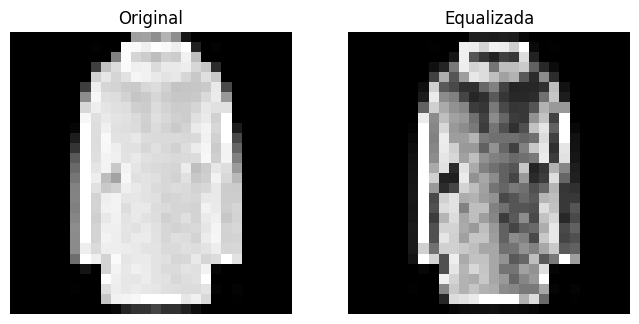

In [13]:
import cv2
import matplotlib.pyplot as plt

img = 6
# Guarda a imagem original
imagem_original = (X[img, :, :, 0] * 255).astype(np.uint8)

# Dataset para armazenar as imagens equalizadas
X_eq = np.empty_like(X)

for i in range(len(X)):
    imagem = (X[i, :, :, 0] * 255).astype(np.uint8)

    imagem_eq = cv2.equalizeHist(imagem)

    # Volta para o intervalo [0,1]
    X_eq[i, :, :, 0] = imagem_eq / 255.0

# Imagem equalizada
imagem_equalizada = X_eq[img, :, :, 0]

# Comparação
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagem_original, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(imagem_equalizada, cmap='gray')
plt.title("Equalizada")
plt.axis('off')

plt.show()

# Atualiza o dataset
X = X_eq

#Separação de Dados

Será novamente separado os dados entre treino e teste, por questões de demonstrar tal funcionalidade e estuda-la. Além disso, essa é uma técnica importante, já que ao utilizar as mesmas imagens tanto no treinamento quanto no teste, ele terá uma alta taxa de acerto apenas porque memorizou os dados, porem nao se sabe se conseguiu realmente aprender a identificar padrões.

In [14]:
from sklearn.model_selection import train_test_split

#Separação entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("Rótulos treino:", y_train.shape)
print("Rótulos teste:", y_test.shape)

Treino: (56000, 28, 28, 1)
Teste: (14000, 28, 28, 1)
Rótulos treino: (56000,)
Rótulos teste: (14000,)


Foi utilizada essa proporção, ja que diante pesquisas, essa é a proporção mais utilizada, por ter uma grande quantidade de imagens para treino, formando o modelo que consegue aprender os padrões, e por outro lado uma quantidade de teste razoávelmente grande com imagens não utilizadas antes, mantendo a confiança do teste.

Além disso a estratificação com base no y foi útil para não ter quantidades desproporcionais de imagens de mesma classe na separação entre teste e treino, podendo ter muitas para teste, e haver pouco ou nennhum para treino. Foi feito em y já que, o importante é ter proporção na quantidade de imagens da mesma classe, e o y é o label que mostra a classe.

In [15]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_index, val_index) in enumerate(skf.split(X, y), start=1):

    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    print(f"----- Fold {fold} -----")

    # Tamanho dos conjuntos
    print("Treino:", X_train.shape)
    print("Validação:", X_val.shape)

    # Distribuição das classes
    print("Classes treino:", np.bincount(y_train))
    print("Classes validação:", np.bincount(y_val))
    print()

----- Fold 1 -----
Treino: (56000, 28, 28, 1)
Validação: (14000, 28, 28, 1)
Classes treino: [5600 5603 5595 5601 5600 5602 5592 5600 5606 5601]
Classes validação: [1401 1400 1399 1400 1400 1400 1398 1400 1402 1400]

----- Fold 2 -----
Treino: (56000, 28, 28, 1)
Validação: (14000, 28, 28, 1)
Classes treino: [5601 5603 5595 5600 5600 5602 5592 5600 5606 5601]
Classes validação: [1400 1400 1399 1401 1400 1400 1398 1400 1402 1400]

----- Fold 3 -----
Treino: (56000, 28, 28, 1)
Validação: (14000, 28, 28, 1)
Classes treino: [5601 5602 5595 5601 5600 5601 5592 5600 5607 5601]
Classes validação: [1400 1401 1399 1400 1400 1401 1398 1400 1401 1400]

----- Fold 4 -----
Treino: (56000, 28, 28, 1)
Validação: (14000, 28, 28, 1)
Classes treino: [5601 5602 5595 5601 5600 5601 5592 5600 5607 5601]
Classes validação: [1400 1401 1399 1400 1400 1401 1398 1400 1401 1400]

----- Fold 5 -----
Treino: (56000, 28, 28, 1)
Validação: (14000, 28, 28, 1)
Classes treino: [5601 5602 5596 5601 5600 5602 5592 5600 560

A validação cruzada se mostra adequada ao mostrar uma avaliaçao confiavel, já que reduz a influência de uma única divisão dos dados. Ela utiliza diferentes subconjuntos para treino e validação, gerando resultados mais estáveis e permitindo uma comparação mais justa entre modelos.

# Modelagem

Foram utilizados um modelo baseline (DummyClassifier) para servir como referência de desempenho e dois modelos de aprendizado de máquina: SGDClassifier e RandomForestClassifier. Ao final, os modelos treinados foram comparados e o de melhor desempenho foi escolhido como modelo final.



**Preparação dos dados**

Tendo como base que os modelos utilizados trabalham com dados que são organizados em forma de tabela, cada imagem de 28 x 28 foi convertida em um vetor de 784 valores, permitindo seu uso pelos classificadores do scikit-learn.

In [16]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

print("Shape treino (flat):", X_train_flat.shape)
print("Shape teste  (flat):", X_test_flat.shape)

Shape treino (flat): (56000, 784)
Shape teste  (flat): (14000, 784)


**Baseline**

O DummyClassifier foi utilizado como um modelo de referência. Pelo fato de sempre prevê a classe mais frequente do conjunto de treinamento, esse modelo permite verificar se os demais modelos conseguem aprender padrões presentes nos dados.

In [17]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train_flat, y_train)
y_pred_baseline = baseline.predict(X_test_flat)

print("Baseline treinado.")

Baseline treinado.


**Modelos Escolhidos:**

**SGDClassifier**

Modelo linear treinado por gradiente descendente estocástico. Neste caso foi utilizada a função de perda hinge, equivalente a uma SVM linear.

In [18]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
sgd.fit(X_train_flat, y_train)
y_pred_sgd = sgd.predict(X_test_flat)

print("SGDClassifier treinado.")

SGDClassifier treinado.


**Random Forest**

Conjunto de árvores de decisão que trabalham em conjunto. A classificação final é obtida pela votação entre as árvores, tornando o modelo mais robusto e reduzindo o risco de decisões baseadas em apenas uma árvore.

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_flat, y_train)
y_pred_rf = rf.predict(X_test_flat)

print("RandomForestClassifier treinado.")

RandomForestClassifier treinado.


**Comparação dos modelos**

A acurácia é utilizada para comparar o desempenho
dos modelos sobre o conjunto de teste reservado.

In [44]:
from sklearn.metrics import accuracy_score
import pandas as pd

resultados = {
    "Modelo": ["Baseline (DummyClassifier)", "SGDClassifier", "RandomForestClassifier"],
    "Acurácia": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_sgd),
        accuracy_score(y_test, y_pred_rf),
    ]
}

df_resultados = pd.DataFrame(resultados)
df_resultados["Acurácia"] = df_resultados["Acurácia"].map(lambda x: f"{x:.4f} ({x*100:.2f}%)")
print("\nComparação de acurácia:")
print(df_resultados.to_string(index=False))


Comparação de acurácia:
                    Modelo        Acurácia
Baseline (DummyClassifier) 0.1001 (10.01%)
             SGDClassifier 0.8541 (85.41%)
    RandomForestClassifier 0.9788 (97.88%)


**Justificativa**

O RandomForestClassifier apresentou a maior acurácia entre os modelos avaliados e, por isso, foi escolhido como modelo final. O DummyClassifier foi utilizado apenas como baseline, enquanto o SGDClassifier apresentou desempenho intermediário. Dessa forma, o RandomForestClassifier foi considerado o modelo mais adequado para este conjunto de dados.

# Avaliação e Discussão

Há a avaliação dos modelos treinados sobre o conjunto de teste reservado. Para cumprir esse objetivo, são utilizadas métricas adequadas para classificação multiclasse, sendo elas: acurácia, precisão, revocação e F1-score, além de matrizes de confusão e relatórios por classe, permitindo identificar onde cada modelo acerta e onde erra.

**Análise de métricas**


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

modelos = {
    "Baseline":      (y_pred_baseline, "gray"),
    "SGDClassifier": (y_pred_sgd,      "steelblue"),
    "RandomForest":  (y_pred_rf,       "seagreen"),
}

print("MÉTRICAS POR MODELO")

metricas_consolidadas = []

for nome, (y_pred, _) in modelos.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    metricas_consolidadas.append({
        "Modelo":     nome,
        "Acurácia":   acc,
        "Precisão":   prec,
        "Revocação":  rec,
        "F1-score":   f1,
    })
    print(f"\n{nome}")
    print(f"  Acurácia : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precisão : {prec:.4f}")
    print(f"  Revocação: {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")

df_metricas = pd.DataFrame(metricas_consolidadas)

MÉTRICAS POR MODELO

Baseline
  Acurácia : 0.1001 (10.01%)
  Precisão : 0.0100
  Revocação: 0.1001
  F1-score : 0.0182

SGDClassifier
  Acurácia : 0.8541 (85.41%)
  Precisão : 0.8549
  Revocação: 0.8541
  F1-score : 0.8537

RandomForest
  Acurácia : 0.9788 (97.88%)
  Precisão : 0.9788
  Revocação: 0.9788
  F1-score : 0.9787


É perceptível o destaque do RandomForest frente aos outros dois modelos, sendo um deles usado como base de referência. Seus valores mantêm um equilíbrio alto em todas as métricas utilizadas, superando o SGDClassifier em mais de 10%.

In [42]:
nomes_classes = list(labels_names.values())

for nome, (y_pred, _) in list(modelos.items())[1:]:
    print(f"RELATÓRIO POR CLASSE: {nome}")
    print(classification_report(y_test, y_pred, target_names=nomes_classes, zero_division=0))

RELATÓRIO POR CLASSE: SGDClassifier
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.79      0.83      1400
     Trouser       0.96      0.97      0.97      1401
    Pullover       0.73      0.82      0.77      1399
       Dress       0.82      0.90      0.86      1400
        Coat       0.78      0.71      0.75      1400
      Sandal       0.94      0.93      0.94      1400
       Shirt       0.63      0.62      0.63      1398
     Sneaker       0.93      0.92      0.92      1400
         Bag       0.94      0.94      0.94      1402
  Ankle boot       0.93      0.94      0.94      1400

    accuracy                           0.85     14000
   macro avg       0.85      0.85      0.85     14000
weighted avg       0.85      0.85      0.85     14000

RELATÓRIO POR CLASSE: RandomForest
              precision    recall  f1-score   support

 T-shirt/top       0.97      0.98      0.97      1400
     Trouser       1.00      0.99      1.00      1401
    Pul

A partir do relatório, é possível observar que o SGDClassifier apresenta maior dificuldade nas classes Shirt, Coat e Pullover, visto que são roupas com silhueta semelhante que o modelo linear tende a confundir. Já o RandomForest mantém F1-score alto em todas as classes, com desempenho mais constante, o que indica maior capacidade de separar classes visualmente próximas.

**Gráficos**


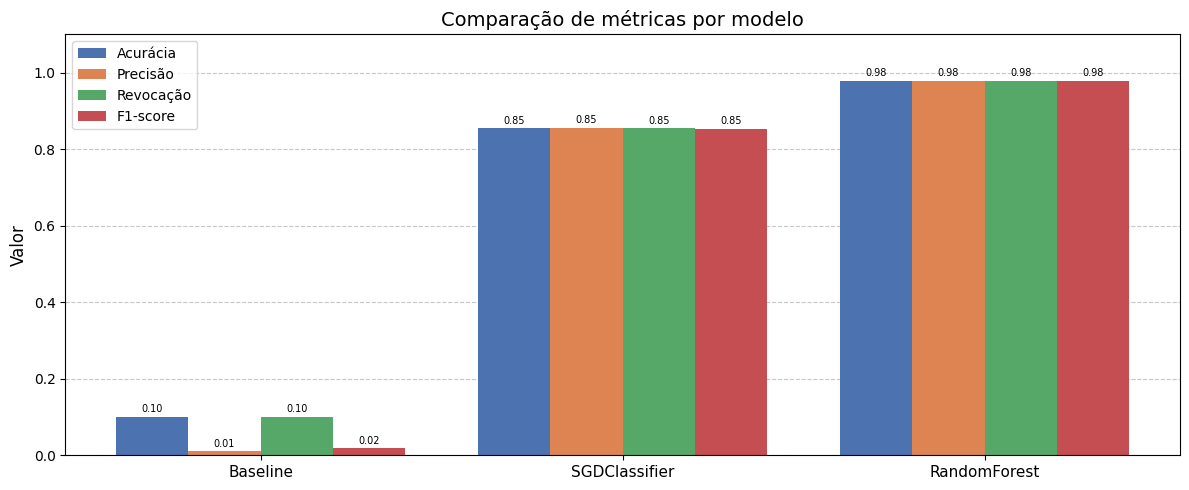

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(df_metricas))
width = 0.2
metricas_plot = ["Acurácia", "Precisão", "Revocação", "F1-score"]
cores = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, metrica in enumerate(metricas_plot):
    ax.bar(x + i * width, df_metricas[metrica], width, label=metrica, color=cores[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_metricas["Modelo"], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Valor", fontsize=12)
ax.set_title("Comparação de métricas por modelo", fontsize=14)
ax.legend(loc="upper left")
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)

plt.tight_layout()
plt.show()

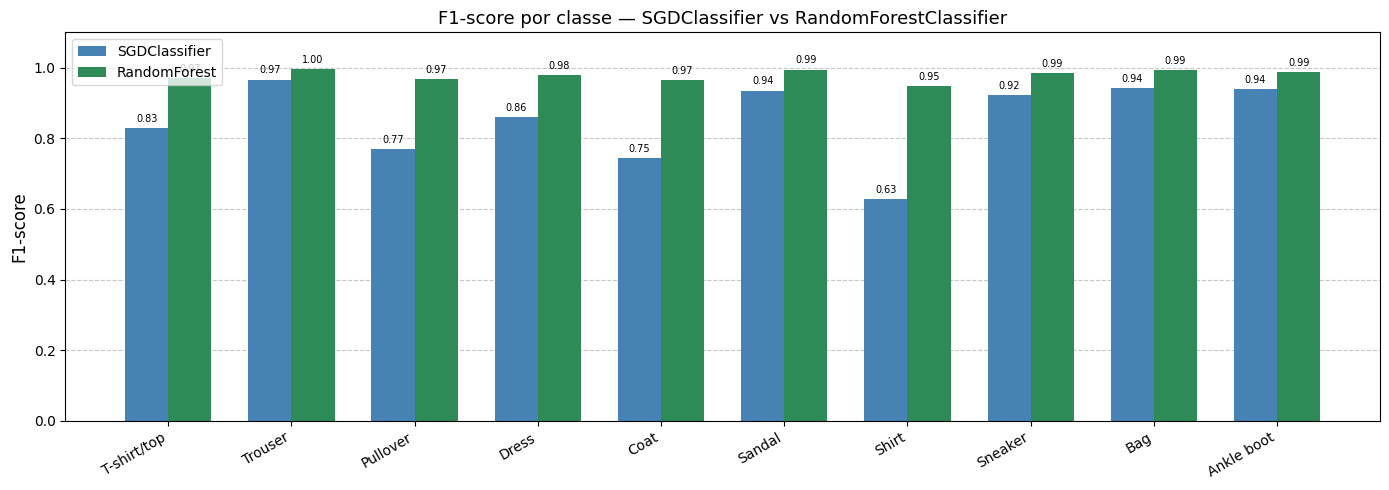

In [41]:
from sklearn.metrics import f1_score as f1_per_class

f1_sgd = f1_score(y_test, y_pred_sgd, average=None, zero_division=0)
f1_rf  = f1_score(y_test, y_pred_rf,  average=None, zero_division=0)

x = np.arange(len(nomes_classes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, f1_sgd, width, label="SGDClassifier", color="steelblue")
ax.bar(x + width/2, f1_rf,  width, label="RandomForest",  color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(nomes_classes, rotation=30, ha="right", fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("F1-score", fontsize=12)
ax.set_title("F1-score por classe — SGDClassifier vs RandomForestClassifier", fontsize=13)
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

for rect in ax.patches:
    h = rect.get_height()
    ax.annotate(f"{h:.2f}",
                xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

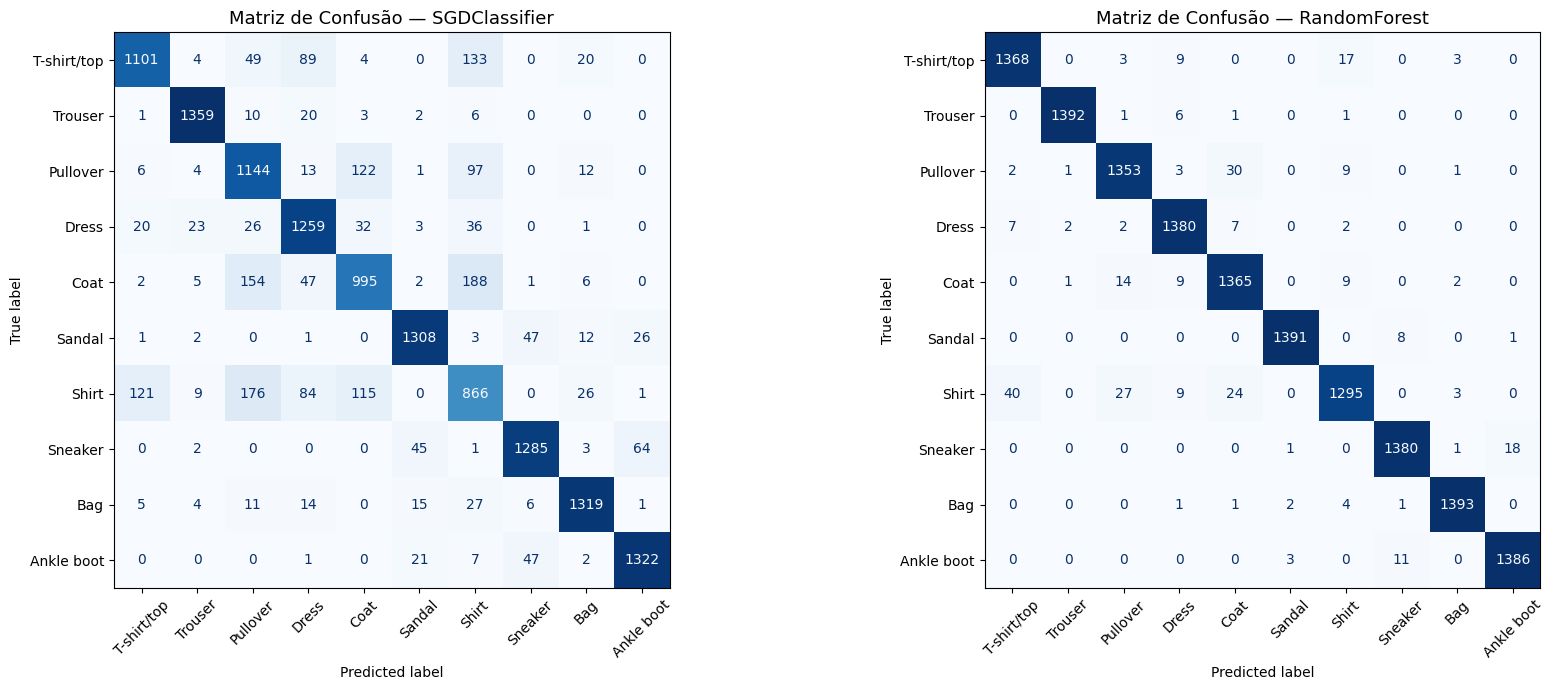

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (nome, (y_pred, _)) in zip(axes, list(modelos.items())[1:]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
    ax.set_title(f"Matriz de Confusão — {nome}", fontsize=13)

plt.tight_layout()
plt.show()

Por meio dos gráficos e das matrizes de confusão, é possível reiterar a melhor escolha de modelo e os padrões de erro relacionados à cada um deles. Na matriz do SGDClassifier, os erros mais frequentes ocorrem entre Shirt, Coat e Pullover, e entre Sandal, Sneaker e Ankle Boot, como já visto anteriormente. Já na matriz do RandomForest percebe-se uma maior dominância na diagonal para as 10 classes apresentadas. Esse comportamento pode ser reforçado no gráfico F1-score por classe, especialmente quanto à Shirt, Coat e Pullover.

In [39]:
melhor_nome = df_metricas.loc[df_metricas["F1-score"].idxmax(), "Modelo"]
melhor_f1   = df_metricas["F1-score"].max()

print(f"""
Modelo escolhido: {melhor_nome}
F1-score (weighted): {melhor_f1:.4f}""")


Modelo escolhido: RandomForest
F1-score (weighted): 0.9787


Por que esse modelo foi escolhido:

  O RandomForestClassifier foi escolhido como modelo final por apresentar o melhor desempenho entre os modelos avaliados, com acurácia de 97.88% e F1-score ponderado de 0.9787 sobre o conjunto de teste. Diferente do SGDClassifier, que é um modelo linear e representa os dados como uma combinação linear dos pixels, o RandomForest é capaz de capturar relações que não são lineares entre regiões da imagem. Isso é relevante para classificação de roupas, onde a combinação de diferentes áreas da imagem define a classe.

Erros observados:

  As principais confusões ocorreram entre classes visualmente similares:
  - Shirt, Coat e Pullover: roupas de cima com silhueta parecida
  - Sandal, Sneaker e Ankle Boot: calçados que diferem em detalhes finos
  Esse padrão de confusão já era esperado a partir da análise exploratória, onde o gráfico PCA mostrou overlap entre essas classes e o heatmap das médias por classe revelou silhuetas similares entre elas.

Limitações:
  1. Estrutura espacial ignorada: ambos os modelos recebem as imagens achatadas em vetores de 784 valores, o que elimina a relação espacial entre pixels vizinhos.
  2. Custo do RandomForest: com 100 árvores e 784 features por amostra, o modelo exige bastante memória e tempo de inferência, o que pode dificultar seu uso em produção ou em dispositivos com recursos limitados.

O que poderia ser melhorado:
  - Utilizar uma Rede Neural Convolucional (CNN), que aproveita a estrutura espacial das imagens e costuma atingir acurácia acima de 92% no Fashion MNIST mesmo em arquiteturas simples.
  - Realizar busca de hiperparâmetros com "GridSearchCV" ou "RandomizedSearchCV" para otimizar parâmetros como "n_estimators" e "max_depth" no RandomForest, e "max_iter" e "loss" no SGDClassifier.
  - Explorar redução de dimensionalidade com PCA antes do SGDClassifier, para reduzir ruído e acelerar o treino sem perda significativa de informação.